## 5. Análise Exploratória dos Dados

In [1]:
import pandas as pd

data_folder = "../data/processed/cleaned_data.csv"

# Load merged data
df_enem = pd.read_csv(data_folder)
df_enem.head()

/home/renan_gonzales/.local/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


,numero_questao,enunciado,alternativas,gabarito,nu_param_B,ano,enunciado_limpo,alternativas_limpo
0,1,A atmosfera terrestre é composta pelos gases n...,A: reduzir o calor irradiado pela Terra median...,C,-1.70677,2009,absorver acontece alternativa anos aquecendo a...,A: calor industrialização irradiado mediante p...
1,2,Analise a figura. Supondo que seja necessário ...,A: Concentração média de álcool no sangue ao l...,D,0.62043,2009,alternativa analise dar figura melhor necessár...,A: concentração dia longo média sangue álcool;...
2,3,Estima-se que haja atualmente no mundo 40 milh...,"A: induzir a imunidade, para proteger o organi...",A,2.07704,2009,acompanhamento aids antiviral atualmente caren...,A: contaminação imunidade induzir organismo pr...
3,4,"Em um experimento, preparou-se um conjunto de ...",A: os genótipos e os fenótipos idênticos.; B: ...,B,0.11500,2009,alguns amareladas apresentaram apresentava apó...,A: fenótipos genótipos idênticos; B: diferente...
4,5,"Na linha de uma tradição antiga, o astrônomo g...",A: Ptolomeu apresentou as ideias mais valiosas...,E,0.21694,2009,afirmar afirmou alemão anos antiga astronômico...,A: antigas apresentou ideias ptolomeu serem tr...


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

df = df_enem.rename(columns={"nu_param_B": "dificuldade"})
df.head()

,numero_questao,enunciado,alternativas,gabarito,dificuldade,ano,enunciado_limpo,alternativas_limpo
0,1,A atmosfera terrestre é composta pelos gases n...,A: reduzir o calor irradiado pela Terra median...,C,-1.70677,2009,absorver acontece alternativa anos aquecendo a...,A: calor industrialização irradiado mediante p...
1,2,Analise a figura. Supondo que seja necessário ...,A: Concentração média de álcool no sangue ao l...,D,0.62043,2009,alternativa analise dar figura melhor necessár...,A: concentração dia longo média sangue álcool;...
2,3,Estima-se que haja atualmente no mundo 40 milh...,"A: induzir a imunidade, para proteger o organi...",A,2.07704,2009,acompanhamento aids antiviral atualmente caren...,A: contaminação imunidade induzir organismo pr...
3,4,"Em um experimento, preparou-se um conjunto de ...",A: os genótipos e os fenótipos idênticos.; B: ...,B,0.11500,2009,alguns amareladas apresentaram apresentava apó...,A: fenótipos genótipos idênticos; B: diferente...
4,5,"Na linha de uma tradição antiga, o astrônomo g...",A: Ptolomeu apresentou as ideias mais valiosas...,E,0.21694,2009,afirmar afirmou alemão anos antiga astronômico...,A: antigas apresentou ideias ptolomeu serem tr...


# Análise Preliminar

Dado que `nu_param_B` (aka. `dificuldade`, por aqui) é a variável target, desnecessário focar em questões em que esta não foi calculada

In [3]:
df.isna().sum()

numero_questao         0
enunciado              6
alternativas          13
gabarito              12
dificuldade           28
ano                    0
enunciado_limpo        7
alternativas_limpo    26
dtype: int64

In [4]:
df = df[df['dificuldade'].notna()]

In [5]:
df.describe()

,dificuldade,ano
count,658.000000,658.000000
mean,1.367985,2016.016717
std,0.898553,4.296970
min,-1.800920,2009.000000
25%,0.812638,2012.000000
50%,1.403490,2016.000000
75%,1.869953,2020.000000
max,8.961860,2023.000000


## **Análise da Dificuldade**

Text(0, 0.5, 'Frequência')

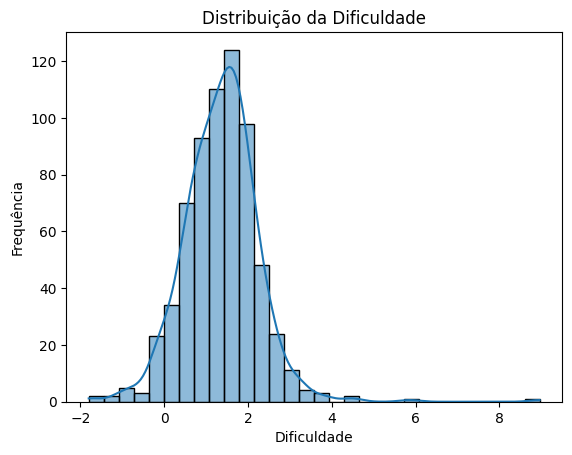

In [6]:
sns.histplot(df['dificuldade'], bins=30, kde=True)
plt.title('Distribuição da Dificuldade')
plt.xlabel('Dificuldade')
plt.ylabel('Frequência')

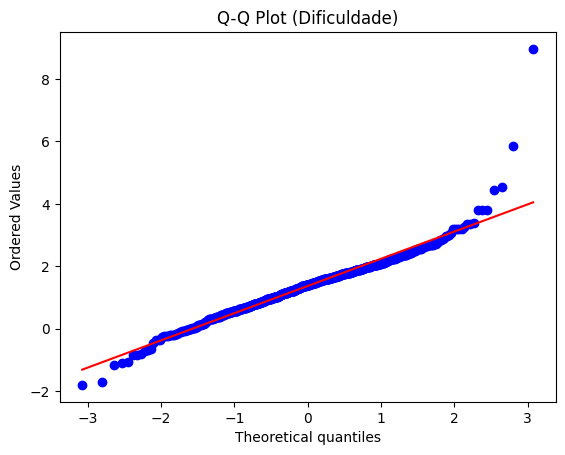

In [7]:
stats.probplot(df['dificuldade'], dist="norm", plot=plt)
plt.title('Q-Q Plot (Dificuldade)')
plt.show()

In [8]:
stat, p = stats.shapiro(df[df['dificuldade'].notna()]['dificuldade'])
print(f"Estatística de teste: {stat:.4f} | p-valor: {p:.4f}")

if p > 0.05:
    print("Não rejeita H_0: distribuição normal.")
else:
    print("Rejeita H_0: exclui distribuição normal.")


Estatística de teste: 0.9390 | p-valor: 0.0000
Rejeita H_0: exclui distribuição normal.


Com a exclusão da distribuição normal, necessário o grupo se atentar se o modelo de predição possui sensibilidade à distribuição. 

Caso seja, possível aplicar Box-Cox.

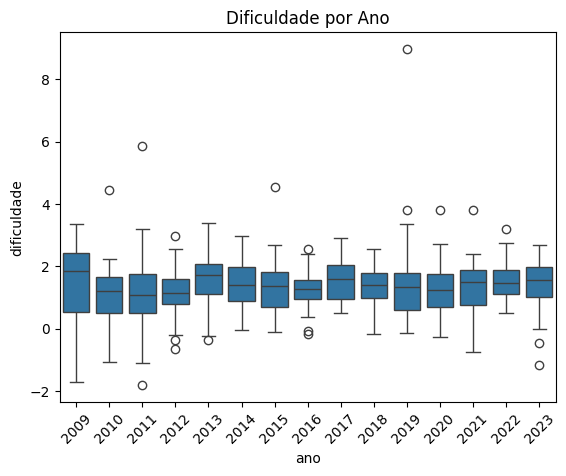

In [9]:
sns.boxplot(x='ano', y='dificuldade', data=df, order=sorted(df["ano"].unique()))
plt.title('Dificuldade por Ano')
plt.xticks(rotation=45)

plt.show()

In [10]:
def max_sem_outlier(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    return group[group <= limite_superior].max()  

max_por_ano = df.groupby('ano')['dificuldade'].apply(max_sem_outlier)
max_por_ano

ano
2009    3.35507
2010    2.22673
2011    3.19792
2012    2.54600
2013    3.38570
2014    2.97259
2015    2.67280
2016    2.39204
2017    2.91532
2018    2.55861
2019    3.36471
2020    2.72331
2021    2.40950
2022    2.76588
2023    2.67412
Name: dificuldade, dtype: float64

O corte de dificuldade 3, feito no artigo, não parece de todo arbitrário.

Afinal, na maioria dos anos, o máximo de dificuldade (excluídos os outliers) não ultrapassa 3 frequentemente. Como sugestão, possível utilizar o corte do máximo da lista (ano de 2013, com 3.38570)

# **Análise enunciados**

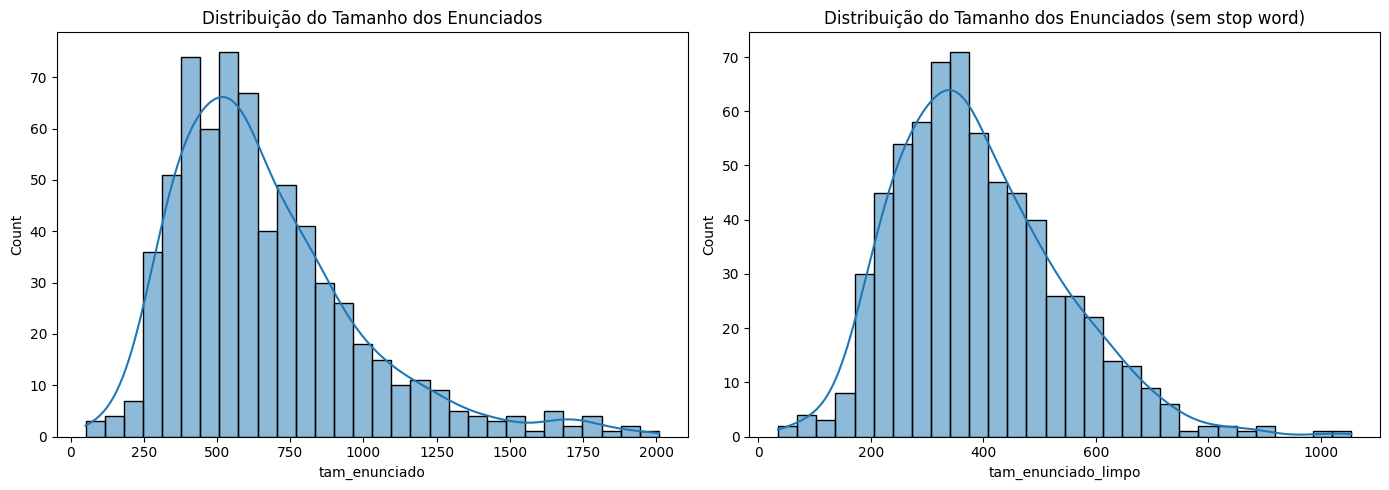

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['tam_enunciado'] = df['enunciado'].str.len()
df['tam_enunciado_limpo'] = df['enunciado_limpo'].str.len()

sns.histplot(df['tam_enunciado'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribuição do Tamanho dos Enunciados')

sns.histplot(df['tam_enunciado_limpo'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Distribuição do Tamanho dos Enunciados (sem stop word)')

plt.tight_layout()
plt.show()

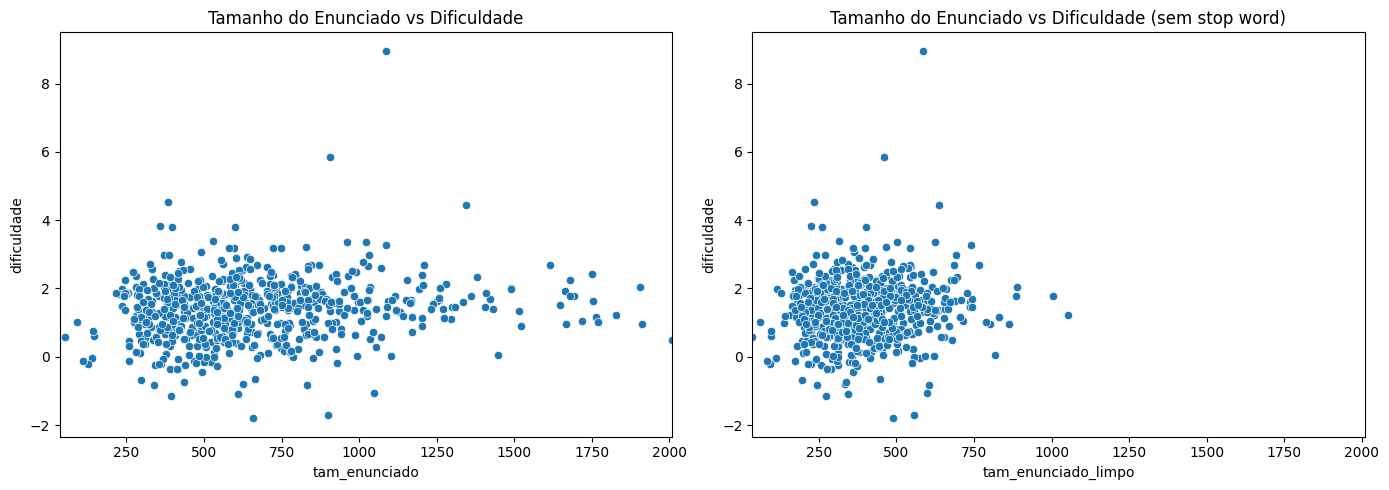

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x='tam_enunciado', y='dificuldade', data=df, ax=axes[0])
axes[0].set_title('Tamanho do Enunciado vs Dificuldade')

sns.scatterplot(x='tam_enunciado_limpo', y='dificuldade', data=df, ax=axes[1])
axes[1].set_title('Tamanho do Enunciado vs Dificuldade (sem stop word)')

x_min = df['tam_enunciado_limpo'].min()
x_max = df['tam_enunciado'].max()
axes[0].set_xlim(x_min, x_max)
axes[1].set_xlim(x_min, x_max)

plt.tight_layout()
plt.show()

Não se verifica um correlação direta entre o tamanho do enunciado e a dificuldade da questão, muito embora se verifique uma pequena concentração entre 0 e 2 nos menores enunciados.

## **Análise de Gabarito**

<Axes: title={'center': 'Distribuição de Alternativas Corretas'}, xlabel='gabarito'>

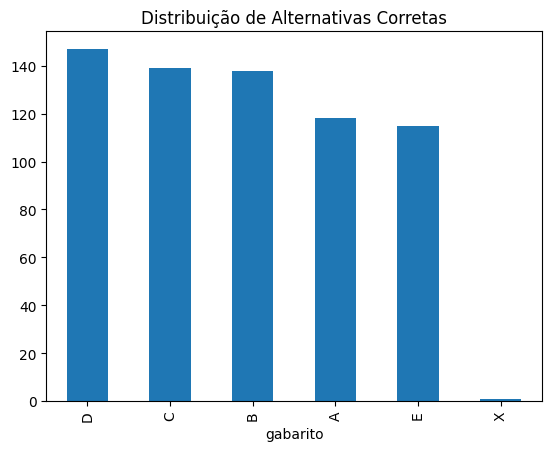

In [13]:
df['gabarito'].value_counts().plot(kind='bar', title='Distribuição de Alternativas Corretas')

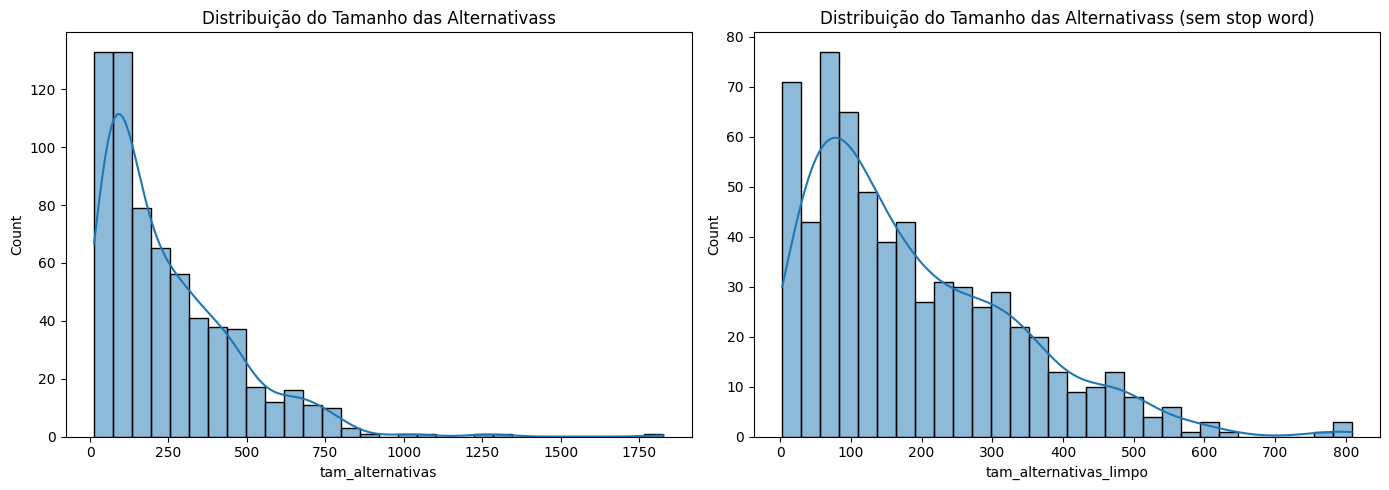

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['tam_alternativas'] = df['alternativas'].str.len()
df['tam_alternativas_limpo'] = df['alternativas_limpo'].str.len()

sns.histplot(df['tam_alternativas'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribuição do Tamanho das Alternativass')

sns.histplot(df['tam_alternativas_limpo'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Distribuição do Tamanho das Alternativass (sem stop word)')

plt.tight_layout()
plt.show()

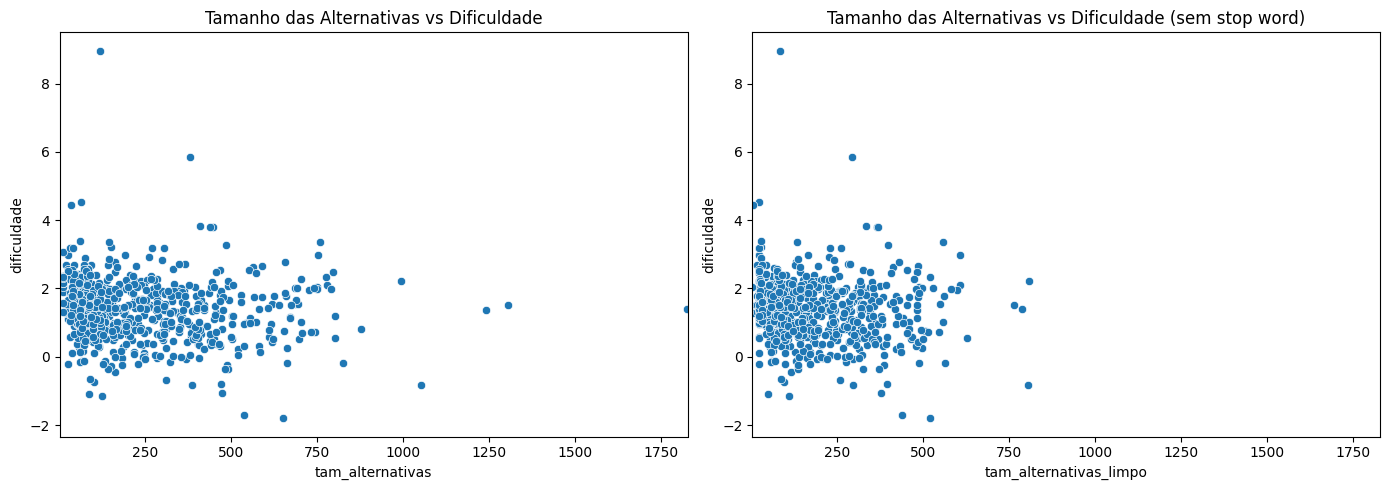

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x='tam_alternativas', y='dificuldade', data=df, ax=axes[0])
axes[0].set_title('Tamanho das Alternativas vs Dificuldade')

sns.scatterplot(x='tam_alternativas_limpo', y='dificuldade', data=df, ax=axes[1])
axes[1].set_title('Tamanho das Alternativas vs Dificuldade (sem stop word)')

x_min = df['tam_alternativas_limpo'].min()
x_max = df['tam_alternativas'].max()
axes[0].set_xlim(x_min, x_max)
axes[1].set_xlim(x_min, x_max)

plt.tight_layout()
plt.show()

# WordCloud (Gabarito e Alternativas)

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

In [17]:
def get_wordcloud(df, col):
    # 1. Filtrar os dados
    df_counter = df.dropna(subset=[col])  # Remove NaN
    median_dif = df_counter['dificuldade'].median()

    # 2. Textos para cada grupo
    text_total = ' '.join(df_counter[col])
    text_hard = ' '.join(df_counter[df_counter['dificuldade'] > median_dif][col])
    text_easy = ' '.join(df_counter[df_counter['dificuldade'] <= median_dif][col])

    # 3. Configurar as nuvens
    wordcloud_total = WordCloud(width=600, height=300, background_color='white').generate(text_total)
    wordcloud_hard = WordCloud(width=600, height=300, background_color='white').generate(text_hard)
    wordcloud_easy = WordCloud(width=600, height=300, background_color='white').generate(text_easy)

    # 4. Plotar em uma linha
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Nuvem 1: Total
    axes[0].imshow(wordcloud_total, interpolation='bilinear')
    axes[0].set_title('Todos os Enunciados', fontsize=12)
    axes[0].axis('off')

    # Nuvem 2: Maior dificuldade
    axes[1].imshow(wordcloud_hard, interpolation='bilinear')
    axes[1].set_title(f'Maior Dificuldade ( > {median_dif:.2f})', fontsize=12)
    axes[1].axis('off')

    # Nuvem 3: Menor dificuldade
    axes[2].imshow(wordcloud_easy, interpolation='bilinear')
    axes[2].set_title(f'Menor Dificuldade ( ≤ {median_dif:.2f})', fontsize=12)
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

In [18]:
def get_word_frequencies(df, col, top_n = 10):
    # 1. Filtrar os dados
    df_counter = df.dropna(subset=[col])
    median_dif = df_counter['dificuldade'].median()

    # 2. Definir os grupos
    text_total = df_counter[col]
    text_hard = df_counter[df_counter['dificuldade'] > median_dif][col]
    text_easy = df_counter[df_counter['dificuldade'] <= median_dif][col]

    # 3. Contar palavras (top 10 em cada grupo)
    def get_top_words(text_series, n=top_n):
        vectorizer = CountVectorizer()
        X = vectorizer.fit_transform(text_series)
        word_counts = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out()).sum()
        return word_counts.sort_values(ascending=False).head(n)

    top_total = get_top_words(text_total)
    top_hard = get_top_words(text_hard)
    top_easy = get_top_words(text_easy)

    # 4. Plotar histogramas lado a lado
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

    # Histograma 1: Total
    axes[0].barh(top_total.index, top_total.values, color='skyblue')
    axes[0].set_title('Todos os Enunciados')
    axes[0].invert_yaxis()

    # Histograma 2: Alta dificuldade
    axes[1].barh(top_hard.index, top_hard.values, color='salmon')
    axes[1].set_title(f'Maior Dificuldade ( > {median_dif:.2f})')

    # Histograma 3: Baixa dificuldade
    axes[2].barh(top_easy.index, top_easy.values, color='lightgreen')
    axes[2].set_title(f'Menor Dificuldade ( ≤ {median_dif:.2f})')

    plt.tight_layout()
    plt.show()

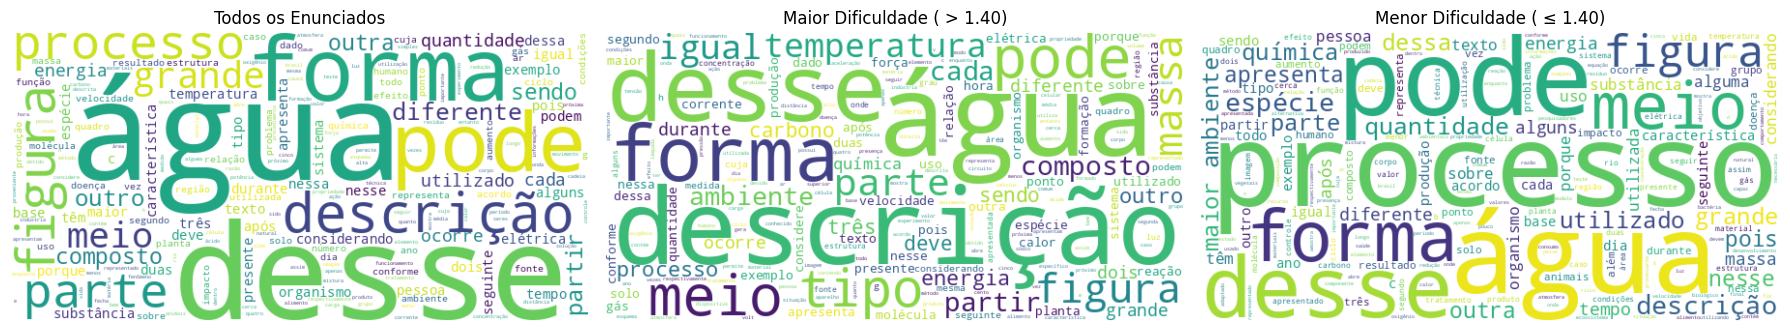

In [19]:
get_wordcloud(df, "enunciado_limpo")

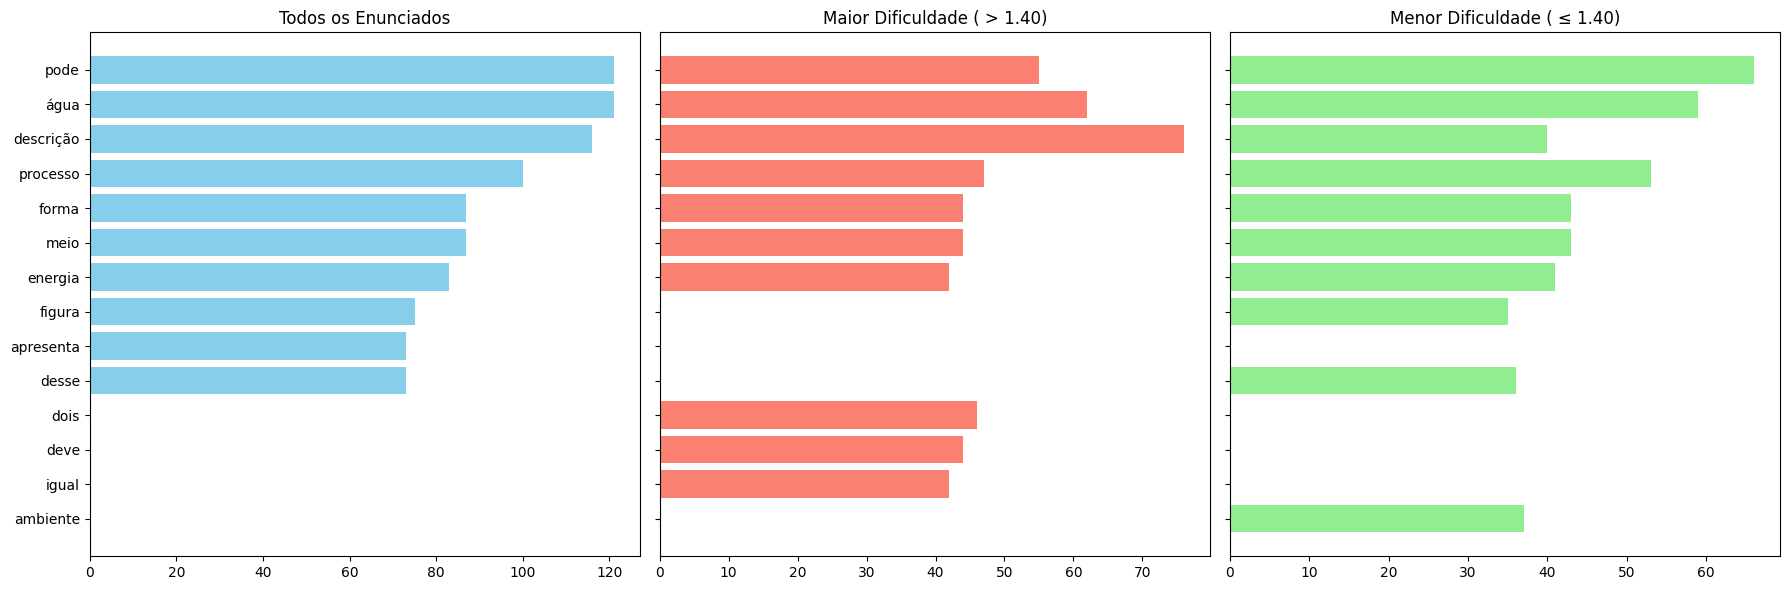

In [20]:
get_word_frequencies(df, "enunciado_limpo")

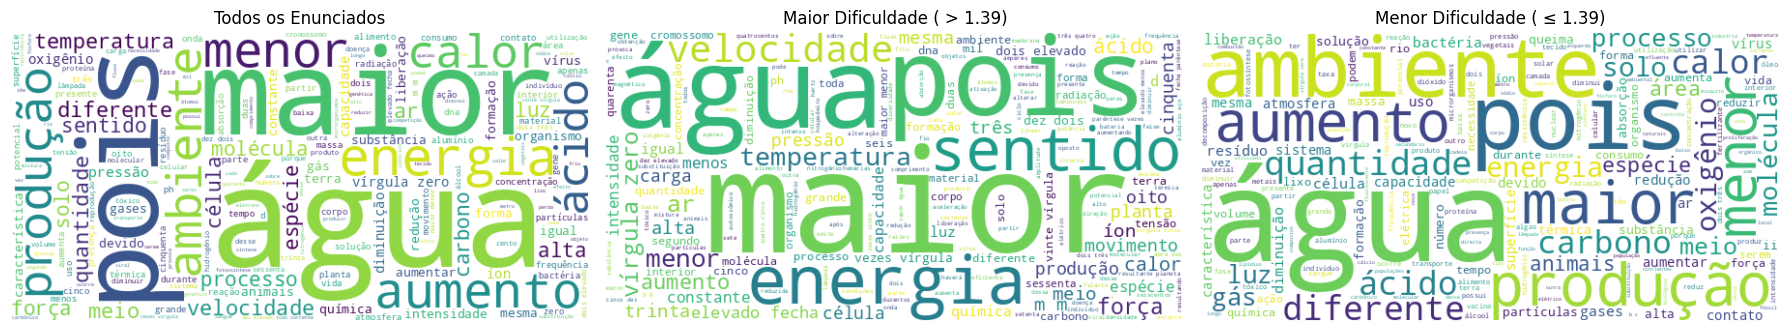

In [21]:
df['alternativas_adap'] = df['alternativas_limpo'].dropna().str.replace(r'[A-E]:\s*', '', regex=True)

get_wordcloud(df, "alternativas_adap")

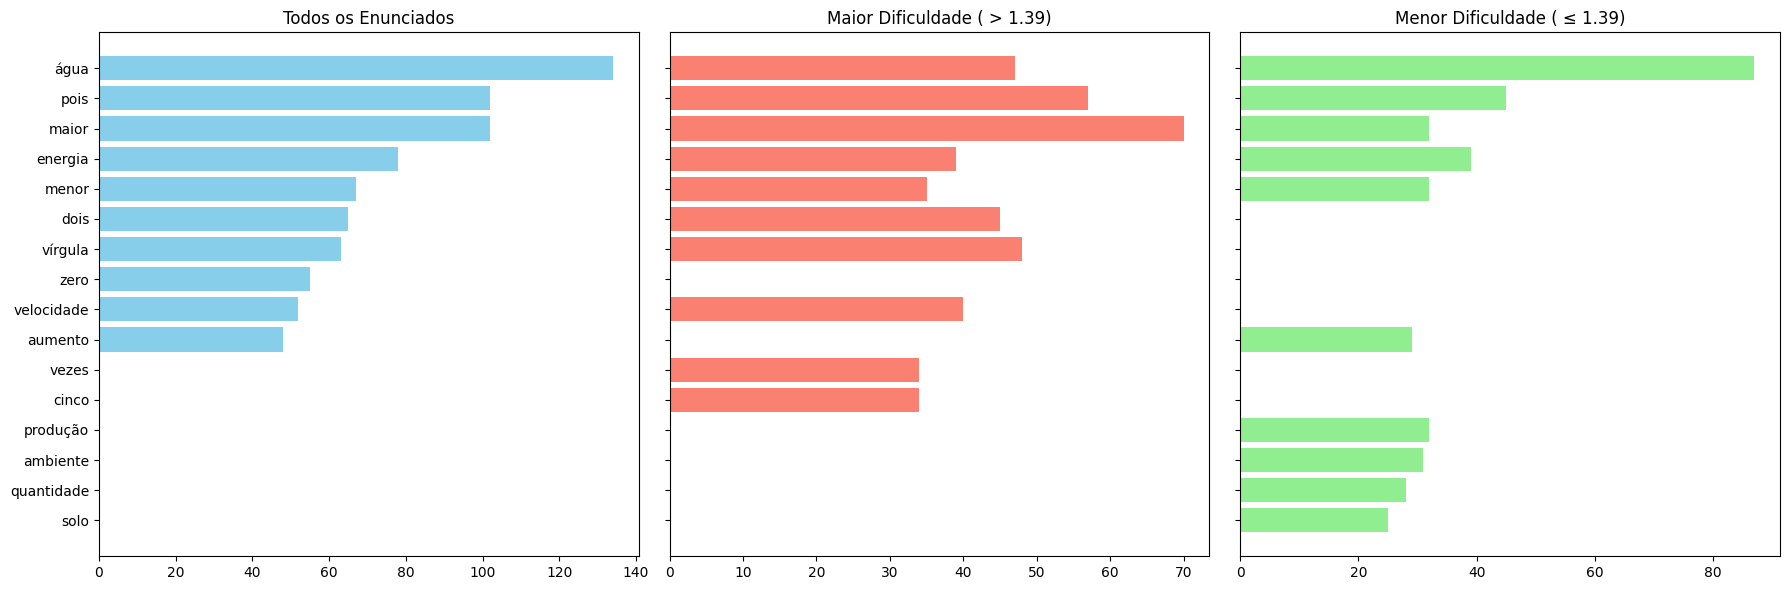

In [22]:
get_word_frequencies(df, "alternativas_adap")